# Notebook 03: Data Preprocessing & Non-IID Hospital Data Partitioning

## Objective
In real-world Federated Healthcare Systems, hospitals specialize in different medical domains:
- **Hospital A**: Specialized Cardiology Center (High proportion of Heart Disease patients).
- **Hospital B**: Specialized Endocrinology & Diabetes Center (High proportion of Diabetes patients).
- **Hospital C**: General Hospital (High proportion of Hypertension & Renal patients).

This non-uniform distribution creates **Non-IID (Not Identically and Independently Distributed)** data across nodes. This notebook partitions the dataset and visualizes feature heterogeneity.



In [1]:
import os
import sys
# Ensure project root is in sys.path for backend and scripts imports
root_path = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if root_path not in sys.path:
    sys.path.insert(0, root_path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.partition_data import partition_data_non_iid

input_csv = os.path.join(root_path, "data", "generated", "synthetic_patients.csv")
output_dir = os.path.join(root_path, "data", "hospitals")

partition_data_non_iid(input_csv, output_dir)
print("Non-IID partitioning complete.")


Non-IID Partitioning Complete:
Hospital A: 514 records
Hospital B: 720 records
Hospital C: 266 records
Non-IID partitioning complete.


## 1. Inspect Hospital Datasets


In [2]:
hosp_a = pd.read_csv(os.path.join(output_dir, "hospital_A.csv"))
hosp_b = pd.read_csv(os.path.join(output_dir, "hospital_B.csv"))
hosp_c = pd.read_csv(os.path.join(output_dir, "hospital_C.csv"))

print(f"Hospital A (Cardiology): {len(hosp_a)} records")
print(f"Hospital B (Diabetes):   {len(hosp_b)} records")
print(f"Hospital C (General):    {len(hosp_c)} records")


Hospital A (Cardiology): 514 records
Hospital B (Diabetes):   720 records
Hospital C (General):    266 records


## 2. Compare Label Prevalence (Non-IID Heterogeneity)


Disease Prevalence (%) Across Hospital Nodes:
                Hospital A  Hospital B  Hospital C
diabetes         59.922179   71.944444   24.812030
heart_disease    20.038911    1.805556    4.887218
hypertension     21.984436   21.250000   21.052632
kidney_disease   34.241245   39.861111   21.052632


<Figure size 1000x500 with 0 Axes>

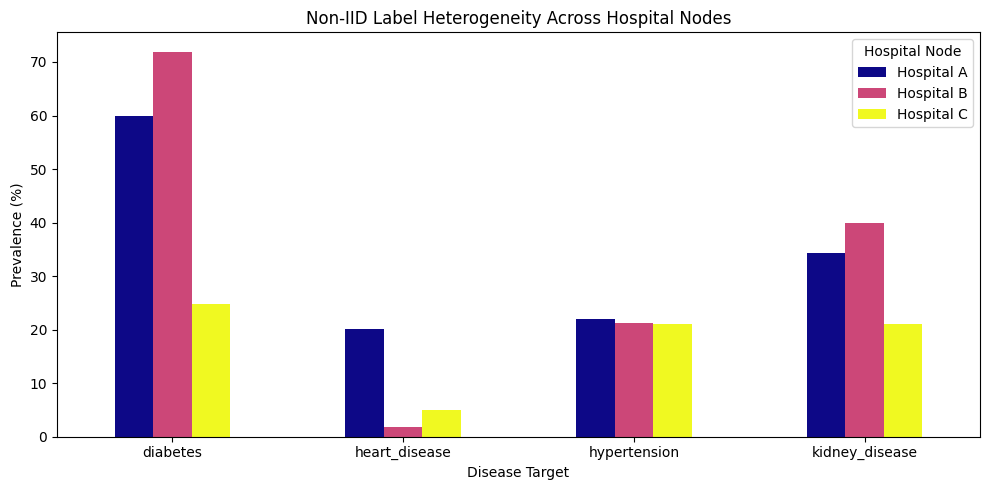

In [3]:
diseases = ['diabetes', 'heart_disease', 'hypertension', 'kidney_disease']

prev_data = {
    'Hospital A': [hosp_a[d].mean() * 100 for d in diseases],
    'Hospital B': [hosp_b[d].mean() * 100 for d in diseases],
    'Hospital C': [hosp_c[d].mean() * 100 for d in diseases],
}

df_prev = pd.DataFrame(prev_data, index=diseases)
print("Disease Prevalence (%) Across Hospital Nodes:")
print(df_prev)

plt.figure(figsize=(10, 5))
df_prev.plot(kind='bar', figsize=(10, 5), colormap='plasma')
plt.title("Non-IID Label Heterogeneity Across Hospital Nodes")
plt.ylabel("Prevalence (%)")
plt.xlabel("Disease Target")
plt.xticks(rotation=0)
plt.legend(title="Hospital Node")
plt.tight_layout()
plt.show()
